
<p style="display:block;text-align:center;font-weight:700;font-size:40px">
  <em>Эссе №6</em>
</p>

<p style="display:block;text-align:center;font-style:italic;font-weight:700;font-size:40px">
  <em>Исследование помехоустойчивого кодирования в AWGN-канале при BPSK</em>
</p>

## **Введение и цели**

В данной работе на простой, но показательной модели передачи BPSK через канал с
аддитивным белым гауссовским шумом (AWGN) исследуются основные принципы
помехоустойчивого кодирования и их влияние на вероятность битовой ошибки (BER).

В ходе работы рассматриваются и сравниваются несколько классов схем передачи:

- **некодированная BPSK** как базовая линия, для которой проводится проверка
  совпадения численных результатов с теоретической формулой
  \(P_b = Q(\sqrt{2E_b/N_0})\);

- **повторный код \((n,1,n)\)** как самый простой способ введения избыточности,
  позволяющий наглядно изучить влияние длины блока и правил принятия решения
  (hard majority и soft-combining), а также показать, почему простое дублирование
  битов не приводит к реальному энергетическому выигрышу при честном сравнении
  по \(E_b/N_0\);

- **код Хэмминга (7,4)** как пример структурированного линейного блочного кода,
  использующего паритетные проверки и синдромное декодирование, и демонстрирующего
  принципиальное отличие между hard-декодированием и soft ML-декодированием
  в канале AWGN;

- **BCH-код (15,7)** как более мощный циклический блочный код с увеличенной
  исправляющей способностью (\(t=2\)), позволяющий исследовать влияние роста
  минимального расстояния и длины блока на BER при использовании оптимального
  soft ML-декодирования.

В работе анализируется:

- **как теоретические параметры кодов** (длина блока, скорость \(R\),
  минимальное расстояние и число исправляемых ошибок) проявляются в численных
  экспериментах в гауссовском канале;

- **как тип декодирования (hard vs soft)** влияет на эффективность одного и того
  же кода и может давать энергетический выигрыш, сопоставимый с переходом к более
  сложной схеме кодирования;

- **какой энергетический выигрыш (coding gain)** достигается различными кодами
  при фиксированном уровне BER и **какова цена этого выигрыша** в виде снижения
  скорости передачи данных.

Таким образом, работа объединяет теоретические понятия помехоустойчивого
кодирования — расстояние Хэмминга, исправляющую способность и роль
soft-информации — с практическим моделированием BPSK+AWGN и количественным
сравнением некодированных и кодированных схем передачи, демонстрируя
компромисс между надёжностью, скоростью и сложностью декодирования,
лежащий в основе проектирования реальных цифровых систем связи.


## **Теория**

##### **Модель BPSK+AWGN и битовая ошибка**

- Передаём двоичный символ через BPSK:
  $$
    0 \;\to\; +\sqrt{E_b}, \qquad 1 \;\to\; -\sqrt{E_b}.
  $$
- Канал с аддитивным белым гауссовским шумом:
  $$
    Y = X + W,\qquad W \sim \mathcal{N}(0,\sigma^2).
  $$
- При жёстком решении по знаку \(Y\) вероятность ошибки на бит:
  $$
    P_b = Q\!\Bigl(\sqrt{2 E_b/N_0}\Bigr),
  $$
  где \(Q(\cdot)\) — Q-функция, \(E_b/N_0\) — отношение энергии на бит к спектральной плотности шума.

---

##### **Блочные коды и параметры \((n,k,d)\)**

- **Блочный код** длины \(n\) и размерности \(k\) сопоставляет каждому блоку из \(k\) информационных битов кодовое слово из \(n\) битов.
- Основные параметры:
  - $n$ — длина кодового слова;
  - $k$ — число информационных битов;
  - $R = k/n$ — **скорость кода**;
  - $d$ — **минимальное расстояние Хэмминга** между различными кодовыми словами.
- Связь между $d$ и корректирующей способностью:
  $$
    t = \Bigl\lfloor\frac{d-1}{2}\Bigr\rfloor,
  $$
  где $t$ — максимальное число ошибок, исправляемое в каждом блоке.
- Код обнаруживает все ошибки веса $\le d-1$.

---

##### **Синдром и синдромное декодирование**

- Принятое слово:
  $$
    r = c + e,
  $$
  где $c$ — кодовое слово, $e$— вектор ошибок.
- **Синдром**:
  $$
    s = H r^T.
  $$
- Так как $Hc^T = 0$, то
  $$
    s = H(c+e)^T = He^T.
  $$
- Синдром зависит **только от ошибки**, а не от исходного сообщения.
- Синдромное декодирование:
  1. заранее вычислить синдромы всех допустимых векторов ошибок;
  2. по принятому синдрому \(s\) определить ошибку \(e\);
  3. исправить:
     $$
       \hat{c} = r + e.
     $$

---

##### **Повторный код \((n,1,n)\)**

- Кодирует один бит повторением:
  $$
    b \;\to\; (b,b,\dots,b).
  $$
- Параметры:
  $$
    (n,k,d) = (n,1,n), \qquad R = 1/n.
  $$
- Декодирование — **правило большинства**.
- Вероятность ошибочного решения блока при ошибке отдельного бита \(p\):
  $$
    P_e^{\text{rep}}(n,p)
      = \sum_{i=\lceil (n+1)/2 \rceil}^{n}
        \binom{n}{i} p^i (1-p)^{n-i}.
  $$
- Код исправляет
  $$
    t = \left\lfloor\frac{n-1}{2}\right\rfloor
  $$
  ошибок, но имеет низкую скорость $R=1/n$.

---

##### **Код Хэмминга (7,4) — минимальный пример «умного» кода**

- Параметры:
  $$
    (n,k,d) = (7,4,3), \qquad R = 4/7.
  $$
- Систематический код: 4 инфо-бита + 3 проверочных.
- Проверочная матрица $H$ имеет уникальный ненулевой столбец для каждой позиции бита.
- Свойство:  
  синдром одиночной ошибки в позиции $i$ равен $i$-му столбцу $H$, поэтому ошибка однозначно локализуется.
- Исправляет **1 ошибку**, обнаруживает до **2 ошибок**.

---

##### **Нормировка по $E_b/N_0$ и скорость кодов**

- При скорости кода $R$ энергия на символ:
  $$
    E_s = \frac{E_b}{R}.
  $$
- Поэтому при сравнении разных кодов корректно использовать шкалу по $E_b/N_0$:
  - коды с меньшим $R$ используют большую энергию на каждый переданный символ;
  - BER сравнивается именно как функция $E_b/N_0$, а не SNR на символ.

---

## **Практика**

In [197]:
import numpy as np
import matplotlib.pyplot as plt
import math

Реализуем вспомогательные функции:
- генератор случайной битовой последовательности
- BPSK модуляция (фазовая манипуляция). Считаем что энергия на бит = 1


In [198]:
def generate_bits(n_bits, rng=None):
    """
    Генерация случайной двоичной последовательности длины n_bits.
    """
    if rng is None:
        rng = np.random.default_rng()
    return rng.integers(0, 2, size=n_bits, dtype=np.int8)


def bpsk_modulate(bits, Eb=1.0):
    """
    BPSK-модуляция: 0 -> +sqrt(Eb), 1 -> -sqrt(Eb)
    """
    return np.where(bits == 0, +np.sqrt(Eb), -np.sqrt(Eb))



Следующая функция будет добавлять к сигналу гауссовский шум такой мощности, чтобы выполнялось заданное $E_b/N_0$

In [199]:
def add_awgn(signal, EbN0_dB, R=1.0, rng=None):
    """
    AWGN для заданного Eb/N0 (в дБ) и скорости кода R.

    Принята нормировка:
      - BPSK символы имеют энергию Es = 1 (амплитуда ±1),
        т.к. bpsk_modulate(..., Eb=1.0) выдаёт ±1.
      - Тогда Eb = Es / R = 1 / R.

    Eb/N0 задано по информационным битам, поэтому:
      sigma^2 = N0/2 = Eb / (2 * (Eb/N0)) = 1 / (2 * R * (Eb/N0)_lin)
    """
    if rng is None:
        rng = np.random.default_rng()

    EbN0_lin = 10**(EbN0_dB / 10.0)
    sigma2 = 1.0 / (2.0 * R * EbN0_lin)
    sigma = np.sqrt(sigma2)

    noise = rng.normal(loc=0.0, scale=sigma, size=signal.shape)
    return signal + noise


Теперь - функции жесткой демодуляции (превращам аналоговое число в бит, сравнивая с порогом) и 

In [200]:
def bpsk_demodulate_hard(received):
    """
    Жёсткое решение для BPSK: по знаку.
    """
    # y >= 0 -> 0, y < 0 -> 1
    return (received < 0).astype(np.int8)


def compute_ber(bits_tx, bits_rx):
    """
    Подсчёт BER: число ошибочных бит / общее число бит.
    """
    assert bits_tx.shape == bits_rx.shape
    errors = np.count_nonzero(bits_tx != bits_rx)
    return errors / bits_tx.size


Функции для подсчета теоретической вероятности ошибки бита в BPSK + AWGN:



Для двоичной фазовой манипуляции (BPSK), передаваемой через AWGN-канал с оптимальным (ML) жёстким приёмом, вероятность ошибки на бит имеет замкнутый аналитический вид: $ P_b = Q\!\bigl(\sqrt{2E_b/N_0}\bigr),$ где \(E_b\) — энергия на бит, \(N_0\) — спектральная плотность шума.

**Q-функция**

Функция $Q(x) определяется как вероятность того, что стандартная нормально распределённая случайная величина превысит значение \(x\):

$
Q(x) = \int_x^{\infty} \frac{1}{\sqrt{2\pi}} e^{-t^2/2}\,dt.
$

Геометрически это площадь «хвоста» стандартного гауссовского распределения правее точки \(x\).

**Интерпретация формулы**

- При передаче символа $+ \sqrt{E_b}$ ошибка возникает, если шум утащит принятый сигнал за порог решения: $  Y = \sqrt{E_b} + W < 0.$
- Это событие эквивалентно $ W < -\sqrt{E_b}, $ где $W \sim \mathcal{N}(0, N_0/2)$.
- Нормировка шумовой случайной величины приводит к выражению через Q-функцию с аргументом $\sqrt{2E_b/N_0}$.

Таким образом, формула
$P_b = Q\!\bigl(\sqrt{2E_b/N_0}\bigr)
$
задаёт **теоретическую нижнюю границу BER** для uncoded BPSK в AWGN-канале и используется как эталон для проверки корректности численного моделирования.


In [201]:
def q_function(x):
    """
    Q(x) = 0.5 * erfc(x / sqrt(2))
    Работает и для скаляров, и для numpy-массивов (через vectorize).
    """
    x = np.asarray(x, dtype=float)
    erfc_vec = np.vectorize(math.erfc)
    return 0.5 * erfc_vec(x / np.sqrt(2.0))

def ber_bpsk_theoretical(EbN0_dB):
    EbN0_lin = 10**(EbN0_dB / 10.0)
    return q_function(np.sqrt(2 * EbN0_lin))



функция строит BER-кривую для uncoded BPSK в AWGN на разных значениях 
$𝐸_𝑏/𝑁_0$ и рядом считает теоретическую BER, чтобы сравнить.

In [202]:
def simulate_ber_uncoded_bpsk(
    EbN0_dB_range,
    n_bits_per_point=100_000,
    rng=None
):
    if rng is None:
        rng = np.random.default_rng()

    ber_sim = []

    for EbN0 in EbN0_dB_range:
        bits = generate_bits(n_bits_per_point, rng=rng)
        tx = bpsk_modulate(bits, Eb=1.0)
        rx = add_awgn(tx, EbN0_dB=EbN0, R=1.0, rng=rng)
        bits_hat = bpsk_demodulate_hard(rx)
        ber_val = compute_ber(bits, bits_hat)
        ber_sim.append(ber_val)

    ber_sim = np.array(ber_sim)
    ber_theory = ber_bpsk_theoretical(np.array(EbN0_dB_range))

    return np.array(EbN0_dB_range), ber_sim, ber_theory


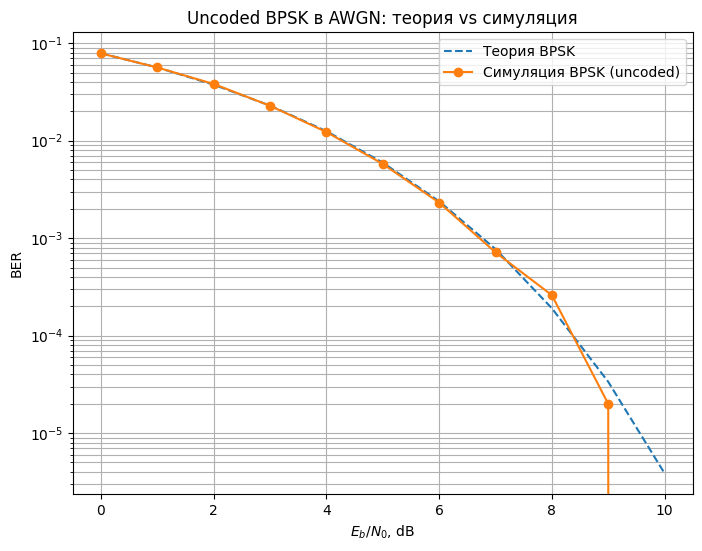

In [203]:
EbN0_dB_range = np.arange(0, 11, 1)  # от 0 до 10 дБ
rng = np.random.default_rng(42)

EbN0_dB, ber_sim, ber_theory = simulate_ber_uncoded_bpsk(
    EbN0_dB_range,
    n_bits_per_point=200_000,
    rng=rng,
)

plt.figure(figsize=(8,6))

plt.semilogy(EbN0_dB, ber_theory, label="Теория BPSK", linestyle="--")
plt.semilogy(EbN0_dB, ber_sim, "o-", label="Симуляция BPSK (uncoded)")

plt.grid(True, which="both")
plt.xlabel(r"$E_b/N_0$, dB")
plt.ylabel("BER")
plt.title("Uncoded BPSK в AWGN: теория vs симуляция")
plt.legend()
plt.show()


Симуляция подтверждает теоретическую зависимость BER для uncoded BPSK в AWGN.   
Расхождения на правом краю — не “ошибка модели”, а ограничение Монте-Карло из-за малого числа наблюдаемых ошибок при высоком  $𝐸_𝑏/𝑁_0$.

Теперь для soft-decoder добавим функцию вычисления LLR: не просто жёсткое решение по знаку 0 или 1, а логарифм отношения вероятностей, то есть насколько уверенно мы можем сказать, что бит был 0 или 1 на основе принятого значения.

In [204]:
def bpsk_llr(received, EbN0_dB, R=1.0):
    """
    Возвращает LLR по каждому принятому символу BPSK.

    Модель как раньше Eb=1):
      sigma^2 = N0/2, N0 = 1/(Eb/N0)
      LLR = log P(b=0|y)/P(b=1|y) = (2 * a / sigma^2) * y
    где a = sqrt(Eb) = 1 (потому что bpsk_modulate(..., Eb=1.0) => +/-1)

    """
    EbN0_lin = 10**(EbN0_dB / 10.0)
    sigma2 = 1.0 / (2.0 * R * EbN0_lin)
    return (2.0 / sigma2) * np.asarray(received, dtype=float)

Напишем простейший повторный кодировщик

In [205]:
def repetition_encode(bits_info, n):
    """
    Повторный код repetition(n,1,n):
    каждый инфо-бит повторяется n раз.
    """
    bits_info = np.asarray(bits_info, dtype=np.int8)
    return np.repeat(bits_info, n)


hard - декодирование повторного кода (голосование по большинству)

In [206]:
def repetition_decode_majority(bits_hard, n):
    """
    Hard-decision декодер: majority vote по каждому блоку длины n.
    Вход: bits_hard (0/1) после bpsk_demodulate_hard.
    Выход: восстановленные инфо-биты (по одному на блок).
    """
    if n % 2 == 0:
        raise ValueError("Для majority vote берём нечётное n (3,5,7,...)")
    b = np.asarray(bits_hard, dtype=np.int8)
    if b.size % n != 0:
        raise ValueError("Длина bits_hard должна быть кратна n")
    blocks = b.reshape(-1, n)
    ones = blocks.sum(axis=1)
    return (ones > (n // 2)).astype(np.int8)

Логика другого декодировщика - та же, но голосование проводится между аналоговыми сигналами, до перевода их в дискретный вид. То есть здесь вес "голоса" пропорционален его "уверенности"

In [207]:

def repetition_decode_softsum(received, n):
    """
    Soft-combining (ML для repetition в AWGN):
    складываем аналоговые received (y_i) в блоке и решаем по знаку суммы.

      S = sum(y_i)
      S>=0 -> 0, иначе 1
    """
    if n % 2 == 0:
        raise ValueError("Обычно берут нечётное n")
    y = np.asarray(received, dtype=float)
    if y.size % n != 0:
        raise ValueError("Длина received должна быть кратна n")
    S = y.reshape(-1, n).sum(axis=1)
    return (S < 0).astype(np.int8)

Проведем тот же эксперимент, только теперь с повторным кодом и 2мя типами декодирования

In [208]:
def simulate_ber_repetition(
    EbN0_dB_range,
    n_rep=3,
    n_info_bits_per_point=100_000,
    decoding="hard",
    rng=None
):
    """
    Считаем BER по ИНФО-битам для repetition(n_rep).

    decoding:
      - "hard": hard demod + majority vote
      - "soft": суммирование внутри блока (soft-combining)
    """
    if rng is None:
        rng = np.random.default_rng()

    R = 1.0 / n_rep
    ber_sim = []

    for EbN0 in EbN0_dB_range:
        bits_info = generate_bits(n_info_bits_per_point, rng=rng)

        bits_code = repetition_encode(bits_info, n_rep)
        tx = bpsk_modulate(bits_code, Eb=1.0)

        rx = add_awgn(tx, EbN0_dB=EbN0, R=R, rng=rng)

        if decoding == "hard":
            hard = bpsk_demodulate_hard(rx)
            bits_hat = repetition_decode_majority(hard, n_rep)
        elif decoding == "soft":
            bits_hat = repetition_decode_softsum(rx, n_rep)
        else:
            raise ValueError("decoding must be 'hard' or 'soft'")

        ber_sim.append(compute_ber(bits_info, bits_hat))

    return np.array(EbN0_dB_range), np.array(ber_sim)


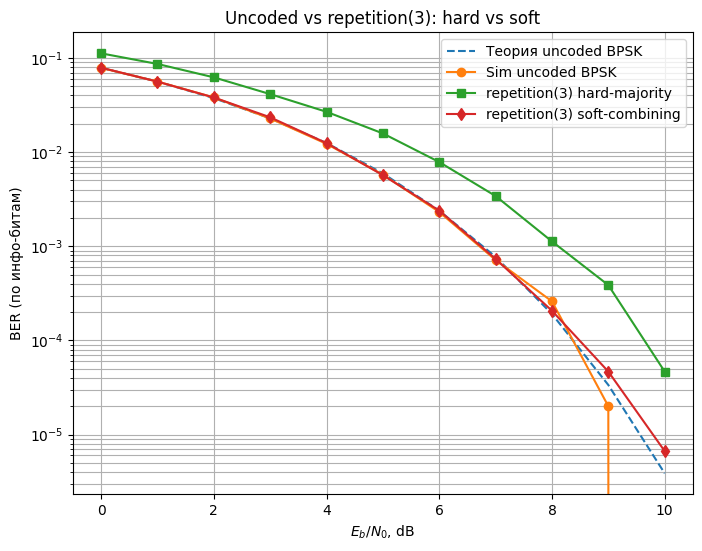

In [209]:
EbN0_dB_range = np.arange(0, 11, 1)
rng = np.random.default_rng(42)


EbN0_dB, ber_unc, ber_th = simulate_ber_uncoded_bpsk(EbN0_dB_range, n_bits_per_point=200_000, rng=rng)

# repetition(3)
_, ber_rep3_h = simulate_ber_repetition(EbN0_dB_range, n_rep=3, n_info_bits_per_point=150_000, decoding="hard", rng=rng)
_, ber_rep3_s = simulate_ber_repetition(EbN0_dB_range, n_rep=3, n_info_bits_per_point=150_000, decoding="soft", rng=rng)

plt.figure(figsize=(8,6))

plt.semilogy(EbN0_dB, ber_th, "--", label="Теория uncoded BPSK")
plt.semilogy(EbN0_dB, ber_unc, "o-", label="Sim uncoded BPSK")

plt.semilogy(EbN0_dB, ber_rep3_h, "s-", label="repetition(3) hard-majority")
plt.semilogy(EbN0_dB, ber_rep3_s, "d-", label="repetition(3) soft-combining")

plt.grid(True, which="both")
plt.xlabel("$E_b/N_0$, dB")
plt.ylabel("BER (по инфо-битам)")
plt.title("Uncoded vs repetition(3): hard vs soft")
plt.legend()
plt.show()


**Вывод по графику: *Uncoded vs repetition(3): hard vs soft***

- **Базовая линия (uncoded BPSK):** симуляция хорошо совпадает с теорией, что подтверждает корректность модели AWGN и нормировки по $E_b/N_0$ — симулятор откалиброван.

- **Repetition(3) с soft-combining практически совпадает с uncoded BPSK.**  
  При честном сравнении по $E_b/N_0$ кривая repetition(3) с soft-декодированием ложится почти точно на кривую uncoded BPSK.  
  Это означает, что при оптимальном (ML) использовании soft-информации повторный код **не даёт ни выигрыша, ни штрафа по энергии**, а лишь перераспределяет ту же энергию инфо-бита между несколькими символами.

- **Repetition(3) с hard-majority заметно хуже.**  
  При hard-декодировании информация об амплитуде отбрасывается, каждый повтор имеет одинаковый “вес”, что приводит к повышенному BER по сравнению как с uncoded BPSK, так и с soft-combining. Потери составляют порядка ~1 dB в области BER $10^{-2}$–$10^{-3}$.

- **Ключевой смысл:** повторный код сам по себе не создаёт coding gain.  
  При оптимальном soft-декодировании repetition(3) лишь **воспроизводит поведение uncoded BPSK**, а при hard-декодировании — даже проигрывает ему.

**Итог:** repetition-код полезен как учебный пример для демонстрации роли soft-информации, но при честном сравнении по $E_b/N_0$ и с учётом скорости $R$ он не обеспечивает энергетического выигрыша и не является эффективным кодом коррекции ошибок.


Теперь для сравнения реализуем "умный" код с самокоррекцией - **код Хэмминга(7, 4)**

In [210]:
# Порядок битов в кодовом слове (позиции 1..7):
# [p1, p2, d1, p4, d2, d3, d4]
# Инфо-биты: позиции 3,5,6,7

HAMMING74_DATA_POS = np.array([2, 4, 5, 6])  # 0-based индексы (3,5,6,7)
HAMMING74_N = 7
HAMMING74_K = 4
HAMMING74_R = HAMMING74_K / HAMMING74_N

# H: 3x7, столбцы — двоичное представление номера позиции (1..7)
# (бит0 = LSB)  => синдром s = H * r^T (mod 2) даст номер ошибочного бита
HAMMING74_H = np.array([    # матрица проверок
    [1, 0, 1, 0, 1, 0, 1],  
    [0, 1, 1, 0, 0, 1, 1],
    [0, 0, 0, 1, 1, 1, 1],
], dtype=np.int8)

# Быстрый маппинг синдрома (0..7) -> индекс бита (0..6) для исправления
# syndrome=0 => исправлять нечего
HAMMING74_SYNDROME_TO_INDEX = {s: (s - 1) for s in range(1, 8)}

Напишем сам кодировщик - на каждые 4 информационных бита составляем блок из 7 бит (добавляет нули в конец если нужно)

In [211]:
def hamming74_encode(bits_info):
    """
    Кодирует поток инфо-битов Hamming(7,4) в порядке [p1 p2 d1 p4 d2 d3 d4].

    Вход:
      bits_info: 1D array 0/1 длины кратной 4 (или будет дополнено нулями)
    Выход:
      code_bits: 1D array 0/1 длины 7 * n_blocks
      n_pad: сколько нулей дописали в конец (чтобы потом можно было отбросить)
    """
    b = np.asarray(bits_info, dtype=np.int8).copy()
    n_pad = (-b.size) % 4
    if n_pad:
        b = np.concatenate([b, np.zeros(n_pad, dtype=np.int8)])

    u = b.reshape(-1, 4)  # [d1 d2 d3 d4] по строкам
    d1, d2, d3, d4 = u[:, 0], u[:, 1], u[:, 2], u[:, 3]

    # Паритеты для стандартного Hamming(7,4) при раскладке [p1 p2 d1 p4 d2 d3 d4]
    # p1 контролирует позиции 1,3,5,7 => p1 = d1 + d2 + d4
    # p2 контролирует позиции 2,3,6,7 => p2 = d1 + d3 + d4
    # p4 контролирует позиции 4,5,6,7 => p4 = d2 + d3 + d4
    p1 = d1 ^ d2 ^ d4
    p2 = d1 ^ d3 ^ d4
    p4 = d2 ^ d3 ^ d4

    c = np.stack([p1, p2, d1, p4, d2, d3, d4], axis=1).astype(np.int8)
    return c.reshape(-1), n_pad

Hard-декодер - принимает блок из 7 бит, находит сидром, исправляет 1 ошибку и возвращает 4 инфо-бита.

In [212]:

def hamming74_decode_syndrome(bits_hard):
    """
    Синдромный hard-декодер Hamming(7,4).

    Вход:
      bits_hard: 1D array 0/1 длины кратной 7
    Выход:
      bits_info_hat: 1D array 0/1 длины 4 * n_blocks
    """
    r = np.asarray(bits_hard, dtype=np.int8)
    if r.size % 7 != 0:
        raise ValueError("Длина bits_hard должна быть кратна 7")

    blocks = r.reshape(-1, 7).copy()

    # синдром s = H r^T (mod 2), где s — 3 бита, которые кодируют номер позиции ошибки (1..7)
    # Преобразуем синдром в число: s_val = s0 + 2*s1 + 4*s2
    s = (blocks @ HAMMING74_H.T) & 1               # (n_blocks, 3)
    s_val = (s[:, 0] + 2*s[:, 1] + 4*s[:, 2]).astype(int)

    # исправление
    for i, sv in enumerate(s_val):
        if sv != 0:
            j = HAMMING74_SYNDROME_TO_INDEX.get(sv, None)
            if j is not None:
                blocks[i, j] ^= 1

    # извлекаем инфо-биты (позиции 3,5,6,7)
    info_hat = blocks[:, HAMMING74_DATA_POS]
    return info_hat.reshape(-1)


Soft - декодер на основе расстояний Евклида. Перебираем все 16 возможных кодовых слов.   
   
HAMMING74_MSGS — все сообщения из 4 бит (16 штук)   
HAMMING74_CODEBITS — соответствующие им кодовые слова (16×7)   
HAMMING74_CODEBPSK — эти кодовые слова, но уже в виде BPSK символов ±1 (16×7)

In [213]:
def _hamming74_build_codebook_bpsk():
    """
    Строит кодбук из 16 кодовых слов:
      messages: (16,4) 0/1
      code_bits: (16,7) 0/1
      code_bpsk: (16,7) +/-1 (BPSK при Eb=1)
    """
    msgs = np.array([[ (m>>3)&1, (m>>2)&1, (m>>1)&1, m&1 ] for m in range(16)], dtype=np.int8)
    c_bits, _ = hamming74_encode(msgs.reshape(-1))
    c_bits = c_bits.reshape(16, 7).astype(np.int8)
    c_bpsk = bpsk_modulate(c_bits.reshape(-1), Eb=1.0).reshape(16, 7).astype(float)
    return msgs, c_bits, c_bpsk

HAMMING74_MSGS, HAMMING74_CODEBITS, HAMMING74_CODEBPSK = _hamming74_build_codebook_bpsk()

Теперь принимаем аналоговые значения $y$ длины кратной 7 и выбрать наиболее вероятное кодовое слово. В случае с AQGN оптимально выбирать кодовое слово, минимизирующее евклидово расстояние $c = arg \ min ​∥y−c∥^2 $

In [214]:

def hamming74_decode_ml(received):
    """
    Soft ML-декодер Hamming(7,4) для AWGN:
    Для каждого блока y (длина 7) выбираем кодовое слово c из 16,
    минимизирующее ||y - c||^2 (евклидова метрика).

    Вход:
      received: 1D array float длины кратной 7 (аналоговые y после канала)
    Выход:
      bits_info_hat: 1D array 0/1 длины 4 * n_blocks
    """
    y = np.asarray(received, dtype=float)
    if y.size % 7 != 0:
        raise ValueError("Длина received должна быть кратна 7")

    Y = y.reshape(-1, 7)  # (B,7)

    # считаем квадраты расстояний до всех 16 кодовых слов
    # dist2[b,m] = sum_k (Y[b,k] - CODEBPSK[m,k])^2
    diff = Y[:, None, :] - HAMMING74_CODEBPSK[None, :, :]   # (B,16,7)
    dist2 = np.sum(diff * diff, axis=2)                     # (B,16)

    best = np.argmin(dist2, axis=1)                         # (B,)
    info_hat = HAMMING74_MSGS[best]                         # (B,4)
    return info_hat.reshape(-1)


Проводим аналогичный предыдущим эксперимент 

In [215]:

def simulate_ber_hamming74(
    EbN0_dB_range,
    n_info_bits_per_point=100_000,
    decoding="hard",   # "hard" или "ml"
    rng=None
):
    """
    BER по ИНФО-битам для Hamming(7,4) в AWGN.

    Использует твои функции:
      - generate_bits
      - bpsk_modulate
      - add_awgn (важно: должен учитывать R!)
      - bpsk_demodulate_hard
      - compute_ber
    """
    if rng is None:
        rng = np.random.default_rng()

    ber_sim = []

    for EbN0 in EbN0_dB_range:
        bits_info = generate_bits(n_info_bits_per_point, rng=rng)

        code_bits, n_pad = hamming74_encode(bits_info)
        tx = bpsk_modulate(code_bits, Eb=1.0)

        rx = add_awgn(tx, EbN0_dB=EbN0, R=HAMMING74_R, rng=rng)

        if decoding == "hard":
            hard = bpsk_demodulate_hard(rx)
            bits_hat = hamming74_decode_syndrome(hard)
        elif decoding == "ml":
            bits_hat = hamming74_decode_ml(rx)
        else:
            raise ValueError("decoding must be 'hard' or 'ml'")

        # отбросить паддинг, если был
        if n_pad:
            bits_hat = bits_hat[:-n_pad]

        ber_sim.append(compute_ber(bits_info, bits_hat))

    return np.array(EbN0_dB_range), np.array(ber_sim)


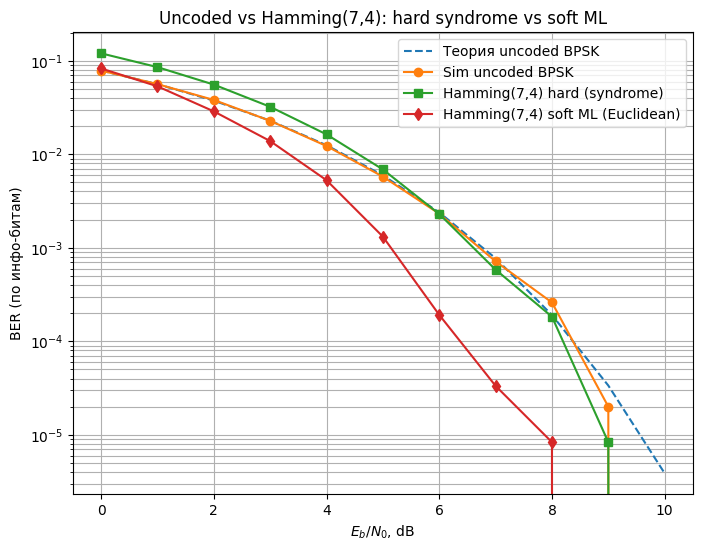

In [216]:

EbN0_dB_range = np.arange(0, 11, 1)
rng = np.random.default_rng(42)

# базовая линия (у тебя уже есть)
EbN0_dB, ber_unc, ber_th = simulate_ber_uncoded_bpsk(EbN0_dB_range, n_bits_per_point=200_000, rng=rng)

# Hamming(7,4)
_, ber_ham_hard = simulate_ber_hamming74(EbN0_dB_range, n_info_bits_per_point=120_000, decoding="hard", rng=rng)
_, ber_ham_ml   = simulate_ber_hamming74(EbN0_dB_range, n_info_bits_per_point=120_000, decoding="ml",   rng=rng)

plt.figure(figsize=(8,6))

plt.semilogy(EbN0_dB, ber_th, "--", label="Теория uncoded BPSK")
plt.semilogy(EbN0_dB, ber_unc, "o-", label="Sim uncoded BPSK")

plt.semilogy(EbN0_dB, ber_ham_hard, "s-", label="Hamming(7,4) hard (syndrome)")
plt.semilogy(EbN0_dB, ber_ham_ml,   "d-", label="Hamming(7,4) soft ML (Euclidean)")

plt.grid(True, which="both")
plt.xlabel(r"$E_b/N_0$, dB")
plt.ylabel("BER (по инфо-битам)")
plt.title("Uncoded vs Hamming(7,4): hard syndrome vs soft ML")
plt.legend()
plt.show()


**Вывод по графику: *Uncoded vs Hamming(7,4): hard syndrome vs soft ML***

- **Калибровка симулятора подтверждена:** кривая *uncoded BPSK (симуляция)* хорошо совпадает с теорией
  $P_b = Q(\sqrt{2E_b/N_0})$. Это означает, что модель AWGN и нормировка по
  $E_b/N_0$ реализованы корректно.

- **Hamming(7,4) с hard синдромным декодером практически совпадает с uncoded BPSK.**  
  При честном сравнении по $E_b/N_0$ и с учётом скорости кода $R=4/7$,
  синдромный hard-декодер в среднем **не даёт заметного энергетического выигрыша**
  относительно uncoded BPSK. Это связано с тем, что hard-декодирование
  отбрасывает soft-информацию, и потенциал кода используется не полностью.

- **Hamming(7,4) с soft ML-декодированием даёт выраженный coding gain.**  
  Кривая *Hamming(7,4) ML* лежит существенно ниже как *uncoded BPSK*, так и
  *Hamming hard*. Использование soft-информации и оптимального ML-критерия
  позволяет эффективно реализовать минимальное расстояние кода и существенно
  снизить BER при том же $E_b/N_0$.

- **Ключевой вывод:** не только структура кода, но и тип декодирования принципиально
  важны. Даже относительно простой код Хэмминга демонстрирует реальный выигрыш
  только при использовании soft-декодирования, тогда как hard-синдромный
  декодер в условиях AWGN практически не превосходит некодированную передачу.

**Итог:** результаты наглядно показывают роль soft-информации и объясняют, почему
в современных системах связи предпочтение отдаётся soft-декодерам и более сложным
алгоритмам декодирования.


После экспериментов с Hamming(7,4) мы увидели, что:

- **тип декодирования критичен:** hard-синдромный декодер использует только знаки (теряет soft-информацию), тогда как ML (soft) даёт заметный выигрыш по BER при том же $E_b/N_0$;
- **структура кода важнее “просто избыточности”:** по сравнению с repetition-кодами Хэмминг уже демонстрирует реальный смысл FEC, особенно при soft-декодировании.

Логичный следующий шаг — проверить, что будет, если:
1) **увеличить длину блока** (с 7 до 15), сохранив циклическую структуру кода;
2) **увеличить исправляющую способность** кода (не только одиночные ошибки, как у Хэмминга, а до двух ошибок в блоке);
3) использовать **soft ML-декодирование** как эталон, чтобы увидеть максимально возможную помехоустойчивость выбранного кода в AWGN.

Для этого выбираем **BCH(15,7)** — более мощный циклический блоковый код с проектным расстоянием $d_{\min}\ge 5$ (то есть с исправлением до $t=2$ ошибок в блоке). Цена за это — меньшая скорость $R=7/15$, но ожидаемый результат — заметное снижение BER при тех же значениях $E_b/N_0$ по сравнению с Hamming(7,4), особенно в области малых BER.


Для начала реализуем функции деления полиномов по mod2 и энкодер BSN(15, 7) (вычисление остатка при делении на генераторный полином)

In [217]:
BCH157_N = 15 # длина кодового слова
BCH157_K = 7 # число информационных бит в блоке
BCH157_M = BCH157_N - BCH157_K  # число проверочных бит = 8
BCH157_R = BCH157_K / BCH157_N # скорость кода

# Генераторный полином BCH(15,7), t=2:
# g(x) = x^8 + x^7 + x^6 + x^4 + x^2 + x + 1
# Коэффициенты от x^8 до x^0:
BCH157_G = np.array([1, 1, 1, 0, 1, 0, 1, 1, 1], dtype=np.int8)

def _poly_mod2_div(dividend, divisor):
    """
    Деление полиномов по mod-2 (XOR).
    dividend, divisor: массивы 0/1, старший коэффициент первым.
    Возвращает remainder (остаток) длины deg(divisor).
    """
    dividend = dividend.copy().astype(np.int8)
    divisor = divisor.astype(np.int8)
    n = dividend.size
    m = divisor.size
    for i in range(n - m + 1):
        if dividend[i] == 1:
            dividend[i:i+m] ^= divisor
    return dividend[-(m-1):]  # степень m-1 -> длина m-1


In [218]:
def bch157_encode(bits_info):
    """
    Систематическое кодирование BCH(15,7):
      c(x) = m(x)*x^8 + r(x),
    где r(x) — остаток от (m(x)*x^8) / g(x).

    Вход:
      bits_info: 1D array 0/1 (длина любая)
    Выход:
      code_bits: 1D array 0/1 длины 15 * n_blocks
      n_pad: сколько нулей дописали до кратности 7
    """
    b = np.asarray(bits_info, dtype=np.int8).copy()
    n_pad = (-b.size) % BCH157_K
    if n_pad:
        b = np.concatenate([b, np.zeros(n_pad, dtype=np.int8)])

    U = b.reshape(-1, BCH157_K)  # блоки по 7 бит
    code_blocks = []

    for u in U:
        shifted = np.concatenate([u, np.zeros(BCH157_M, dtype=np.int8)])  # x^8
        r = _poly_mod2_div(shifted, BCH157_G)  # 8 бит остатка
        c = np.concatenate([u, r]).astype(np.int8)  # [data | parity]
        code_blocks.append(c)

    code_bits = np.concatenate(code_blocks)
    return code_bits, n_pad


Функция, строящая "кодбук" для всех возможных сообщений, для каждого слова строит кодовое слово и переводит кодовые биты в BPSK символы

In [219]:
def _bch157_build_codebook_bpsk():
    """
    Кодбук на все 2^7 сообщений:
      MSGS: (128,7) 0/1
      CODEBPSK: (128,15) +/-1
    """
    M = 2**BCH157_K
    msgs = np.array([[ (i >> (BCH157_K-1-j)) & 1 for j in range(BCH157_K) ] for i in range(M)],
                    dtype=np.int8)
    code_bits, _ = bch157_encode(msgs.reshape(-1))
    code_bits = code_bits.reshape(M, BCH157_N).astype(np.int8)
    code_bpsk = bpsk_modulate(code_bits.reshape(-1), Eb=1.0).reshape(M, BCH157_N).astype(float)
    return msgs, code_bpsk

BCH157_MSGS, BCH157_CODEBPSK = _bch157_build_codebook_bpsk()  # матрица всех 2^7 сообщений и матрица всех 2^7 кодовых слов в BPSK

Soft - ML-декодерирование BCH(15 11) (перебираем все возможные кодовые слова и выбираем ближайшее - > медленно!)

In [220]:
def bch157_decode_ml(received):
    """
    ML-декодирование BCH(15,7) для AWGN (перебор 128 кодовых слов):
    выбираем c минимизирующее ||y - c||^2.

    Вход:
      received: 1D float array длины кратной 15
    Выход:
      bits_info_hat: 1D array 0/1 длины 7 * n_blocks
    """
    y = np.asarray(received, dtype=float)
    if y.size % BCH157_N != 0:
        raise ValueError("Длина received должна быть кратна 15")

    Y = y.reshape(-1, BCH157_N)  # (B,15)

    diff = Y[:, None, :] - BCH157_CODEBPSK[None, :, :]   # (B,128,15)
    dist2 = np.sum(diff * diff, axis=2)                  # (B,128)

    best = np.argmin(dist2, axis=1)                      # (B,)
    info_hat = BCH157_MSGS[best]                         # (B,7)
    return info_hat.reshape(-1)



Оцениваем BER по инфо-битам с ML-декодером на наборе $E_b/N_0$

In [221]:
def simulate_ber_bch157_ml(
    EbN0_dB_range,
    n_info_bits_per_point=140_000,  # удобно кратно 7
    rng=None
):
    """
    BER по инфо-битам для BCH(15,7) с ML-декодером.
    """
    if rng is None:
        rng = np.random.default_rng()

    ber_sim = []

    for EbN0 in EbN0_dB_range:
        bits_info = generate_bits(n_info_bits_per_point, rng=rng)

        code_bits, n_pad = bch157_encode(bits_info)
        tx = bpsk_modulate(code_bits, Eb=1.0)

        rx = add_awgn(tx, EbN0_dB=EbN0, R=BCH157_R, rng=rng)

        bits_hat = bch157_decode_ml(rx)

        if n_pad:
            bits_hat = bits_hat[:-n_pad]

        ber_sim.append(compute_ber(bits_info, bits_hat))

    return np.array(EbN0_dB_range), np.array(ber_sim)


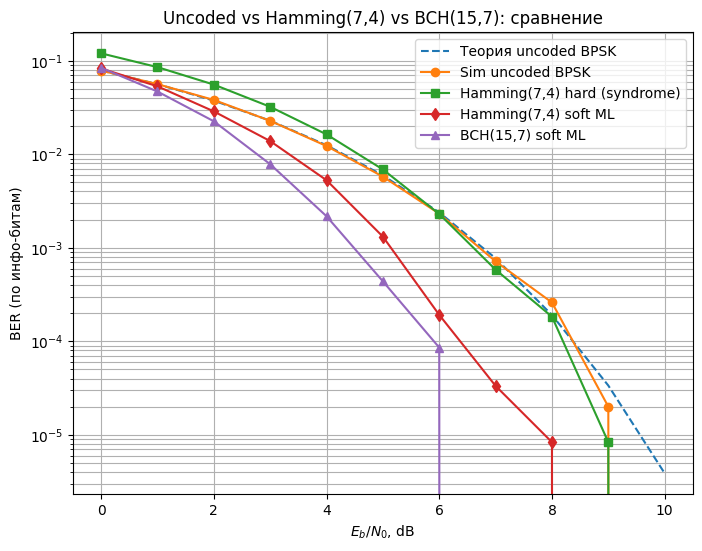

In [222]:
EbN0_dB_range = np.arange(0, 11, 1)
rng = np.random.default_rng(42)

# Uncoded 
EbN0_dB, ber_unc, ber_th = simulate_ber_uncoded_bpsk(EbN0_dB_range, n_bits_per_point=200_000, rng=rng)

# Hamming(7,4) 
_, ber_ham_hard = simulate_ber_hamming74(EbN0_dB_range, n_info_bits_per_point=120_000, decoding="hard", rng=rng)
_, ber_ham_ml   = simulate_ber_hamming74(EbN0_dB_range, n_info_bits_per_point=120_000, decoding="ml",   rng=rng)

# BCH(15,11) ML
_, ber_bch_ml = simulate_ber_bch157_ml(EbN0_dB_range, n_info_bits_per_point=210_000, rng=rng)

plt.figure(figsize=(8,6))

plt.semilogy(EbN0_dB, ber_th, "--", label="Теория uncoded BPSK")
plt.semilogy(EbN0_dB, ber_unc, "o-", label="Sim uncoded BPSK")

plt.semilogy(EbN0_dB, ber_ham_hard, "s-", label="Hamming(7,4) hard (syndrome)")
plt.semilogy(EbN0_dB, ber_ham_ml,   "d-", label="Hamming(7,4) soft ML")

plt.semilogy(EbN0_dB, ber_bch_ml, "^-", label="BCH(15,7) soft ML")

plt.grid(True, which="both")
plt.xlabel(r"$E_b/N_0$, dB")
plt.ylabel("BER (по инфо-битам)")
plt.title("Uncoded vs Hamming(7,4) vs BCH(15,7): сравнение")
plt.legend()
plt.show()


***Вывод по графику: *Uncoded vs Hamming(7,4) vs BCH(15,7)***

- **Uncoded BPSK** демонстрирует наихудшую помехоустойчивость и служит базовой линией для сравнения.

- **Hamming(7,4) с hard-декодированием** практически не превосходит uncoded BPSK, что подчёркивает ограниченность hard-решений и потерю soft-информации в канале AWGN.

- **Hamming(7,4) с soft ML-декодированием** даёт заметный coding gain по сравнению с uncoded BPSK, подтверждая важность использования soft-информации и оптимального критерия декодирования.

- **BCH(15,7) с soft ML-декодированием** демонстрирует **устойчиво лучшую помехоустойчивость** по сравнению с Hamming(7,4) ML на всём диапазоне \(E_b/N_0\). Кривая BCH(15,7) лежит существенно ниже, особенно в области малых BER.

- Существенный выигрыш BCH(15,7) объясняется **большим минимальным расстоянием** \(d_{\min}\ge 5\) и более высокой исправляющей способностью (\(t=2\) ошибки в блоке), тогда как код Хэмминга исправляет только одиночные ошибки (\(t=1\), \(d_{\min}=3\)).

- Цена за рост помехоустойчивости — **уменьшение скорости кода**: \(R=7/15\) для BCH(15,7) против \(R=4/7\) для Hamming(7,4). Тем не менее, при честном сравнении по \(E_b/N_0\) выигрыш по BER оказывается значительно важнее, чем потеря в скорости.

**Итог:** результаты наглядно показывают, что систематическое улучшение помехоустойчивости достигается не за счёт простого увеличения длины блока, а за счёт роста минимального расстояния и исправляющей способности кода. BCH(15,7) иллюстрирует, как увеличение \(d_{\min}\) и использование soft ML-декодирования приводят к существенному снижению BER по сравнению с более простыми кодами.


Помимо графиков полезно свести результаты в одну числовую метрику: для каждой схемы
определим, какое значение $E_b/N_0$ (в дБ) требуется, чтобы достичь заданного уровня
качества связи, например $BER \approx 10^{-3}$.

Для этого по каждой BER-кривой выполняем интерполяцию по $\log_{10}(BER)$ между
соседними точками и находим соответствующее значение $E_b/N_0$. Полученная таблица
позволяет напрямую сравнить **энергетическую эффективность** кодов и типов декодирования.

In [223]:
def ebn0_at_target_ber(EbN0_dB, ber, target=1e-3):
    """
    Находит Eb/N0 (dB), при котором BER ~= target.
    Интерполяция по log10(BER) между соседними точками.
    Возвращает np.nan, если target не достигается в диапазоне.
    """
    EbN0_dB = np.asarray(EbN0_dB, dtype=float)
    ber = np.asarray(ber, dtype=float)

    # выкидываем нули (иначе log10)
    mask = ber > 0
    EbN0_dB = EbN0_dB[mask]
    ber = ber[mask]

    if ber.size < 2:
        return np.nan

    logb = np.log10(ber)
    logt = np.log10(target)

    for i in range(len(EbN0_dB) - 1):
        if (logb[i] >= logt and logb[i+1] <= logt) or (logb[i] <= logt and logb[i+1] >= logt):
            x0, x1 = EbN0_dB[i], EbN0_dB[i+1]
            y0, y1 = logb[i], logb[i+1]
            if y1 == y0:
                return x0
            return x0 + (logt - y0) * (x1 - x0) / (y1 - y0)

    return np.nan


In [224]:
def make_summary_table(EbN0_dB, curves_dict, target=1e-3):
    """
    curves_dict: dict { "Название схемы": ber_array }
    Печатает таблицу Eb/N0 для заданного target BER.
    """
    rows = []
    for name, ber in curves_dict.items():
        eb = ebn0_at_target_ber(EbN0_dB, ber, target=target)
        rows.append((name, eb))

    rows.sort(key=lambda x: (np.nan_to_num(x[1], nan=1e9)))

    print(f"Целевой BER = {target:g}\n")
    print("| Схема | Eb/N0 для BER≈{0:g}, dB |".format(target))
    print("|---|---:|")
    for name, eb in rows:
        if np.isnan(eb):
            print(f"| {name} | не достигнуто |")
        else:
            print(f"| {name} | {eb:.2f} |")

Собираем все реализованные кривые

In [225]:
curves = {
    "Uncoded BPSK (sim)": ber_unc,            
    "Uncoded BPSK (theory)": ber_th,          

    "Repetition(3) hard-majority": ber_rep3_h,
    "Repetition(3) soft-combining": ber_rep3_s,

    "Hamming(7,4) hard (syndrome)": ber_ham_hard,
    "Hamming(7,4) soft ML (Euclidean)": ber_ham_ml,

    "BCH(15,7) soft ML": ber_bch_ml,
}

make_summary_table(EbN0_dB, curves, target=1e-3)

Целевой BER = 0.001

| Схема | Eb/N0 для BER≈0.001, dB |
|---|---:|
| BCH(15,7) soft ML | 4.49 |
| Hamming(7,4) soft ML (Euclidean) | 5.14 |
| Hamming(7,4) hard (syndrome) | 6.61 |
| Uncoded BPSK (sim) | 6.71 |
| Repetition(3) soft-combining | 6.74 |
| Uncoded BPSK (theory) | 6.77 |
| Repetition(3) hard-majority | 8.11 |


Для наглядного количественного сравнения по всем реализованным схемам была
составлена таблица значений $E_b/N_0$, необходимых для достижения уровня
$BER \approx 10^{-3}$.

- **BCH(15,7) с soft ML-декодированием** показал наилучший результат:
  требуемое $E_b/N_0 \approx 4.49$ dB. Это соответствует максимальному
  энергетическому выигрышу среди рассмотренных схем и обусловлено большей
  исправляющей способностью кода $(t=2$, $d_{\min}\ge 5$).

- **Hamming(7,4) с soft ML-декодированием** требует $E_b/N_0 \approx 5.14$ dB,
  что примерно на 0.65 dB хуже по сравнению с BCH(15,7). Разница объясняется тем,
  что код Хэмминга исправляет только одиночные ошибки ($t=1$).

- **Hamming(7,4) с hard синдромным декодированием** даёт значительно худший
  результат $(\approx 6.61$ dB), что подчёркивает ключевую роль использования
  soft-информации при декодировании в канале AWGN.

- **Uncoded BPSK** и **repetition(3) с soft-combining** требуют практически
  одинакового $E_b/N_0$ (около 6.7 dB), что подтверждает отсутствие
  энергетического выигрыша у повторного кода при честном сравнении по $E_b/N_0$.

- **Repetition(3) с hard-majority** является наименее эффективной схемой
  ($\approx 8.11$ dB), демонстрируя существенные потери из-за выбрасывания
  soft-информации и неэффективной структуры кода.

**Итог:** численные результаты подтверждают выводы по графикам: реальный
энергетический выигрыш достигается только при использовании кодов с большей
исправляющей способностью и soft-декодирования. **BCH(15,7)** является наиболее
эффективной схемой среди рассмотренных при выбранном уровне BER.

## **Результаты и применимость**

### Краткие выводы экспериментов

- Для канала AWGN с BPSK **теоретическая зависимость**
  \[
  P_b = Q\!\left(\sqrt{2\,E_b/N_0}\right)
  \]
  практически полностью совпала с результатами Монте-Карло для некодированной передачи.
  Это подтверждает корректность модели канала, нормировки по \(E_b/N_0\) и всей
  инфраструктуры симуляции.

- **Повторные коды (repetition)** при честном сравнении по \(E_b/N_0\) не дают
  энергетического выигрыша:
  при soft-combining они практически совпадают с uncoded BPSK,
  а при hard-majority оказываются даже хуже.
  Это наглядно показывает, что избыточность сама по себе не гарантирует
  улучшения помехоустойчивости.

- **Код Хэмминга (7,4)** демонстрирует принципиальную разницу между hard и soft
  декодированием:
  синдромный hard-декодер почти не превосходит uncoded BPSK,
  тогда как soft ML-декодирование даёт заметный coding gain
  (около 1.5 дБ при BER ≈ \(10^{-3}\)).

- **BCH(15,7) с soft ML-декодированием** обеспечивает наилучшую помехоустойчивость
  среди рассмотренных схем.
  При BER ≈ \(10^{-3}\) он требует примерно \(E_b/N_0 \approx 4.5\) дБ,
  что соответствует выигрышу более 2 дБ по сравнению с некодированной BPSK.
  Этот результат обусловлен увеличенным минимальным расстоянием
  (\(d_{\min}\ge 5\)) и исправлением до двух ошибок в блоке.

- Эксперименты подтверждают, что **ключевыми факторами эффективности FEC**
  являются:
  минимальное расстояние кода, исправляющая способность и использование
  soft-информации при декодировании, а не просто длина блока или объём избыточности.

---

### Практический смысл полученных результатов

- **Оценка энергетического выигрыша кодирования.**  
  Таблица \(E_b/N_0\) для заданного BER позволяет напрямую оценить coding gain
  различных схем и количественно сравнивать их между собой.

- **Выбор кода и декодера.**  
  Для AWGN-канала использование soft-декодирования даёт выигрыш, сопоставимый
  с переходом на более сложный код. Это объясняет, почему в реальных системах
  почти всегда применяются soft-декодеры.

- **Компромисс скорость ↔ помехоустойчивость.**  
  Более мощные коды (например, BCH(15,7)) дают существенное снижение BER,
  но за счёт уменьшения скорости \(R\). Выбор кода определяется допустимым
  балансом между пропускной способностью и энергетической эффективностью.

- **Связь с практическими системами.**  
  Полученные результаты иллюстрируют базовую логику построения современных
  систем связи: лестницы MCS, использование FEC с различной исправляющей
  способностью и адаптацию параметров передачи для работы как можно ближе
  к теоретическим пределам при заданных условиях канала.

Несмотря на простоту модели AWGN с BPSK, проведённые эксперименты наглядно
показывают фундаментальные принципы помехоустойчивого кодирования, которые
лежат в основе реальных цифровых систем связи.


## **Литература**

1. [BPSK - Фазовая манипуляция](https://ru.wikipedia.org/wiki/Фазовая_манипуляция)
2. [Теорема Шеннона — Хартли](https://ru.wikipedia.org/wiki/Теорема_Шеннона_—_Хартли)
3. [Аддитивный белый гауссовский шум](https://ru.wikipedia.org/wiki/Аддитивный_белый_гауссовский_шум)
4. [Двоичный симметричный канал](https://ru.wikipedia.org/wiki/Двоичный_симметричный_канал)
6. [Блочный код (Wikipedia)](https://ru.wikipedia.org/wiki/Блочный_код)
7. [Линейный блочный код](https://ru.wikipedia.org/wiki/Линейный_код)
8. [Код Хэмминга](https://ru.wikipedia.org/wiki/Код_Хэмминга)
9. [BCH код](https://ru.wikipedia.org/wiki/Код_Боуза_—_Чоудхури_—_Хоквингема)

10. [Теория помехоустойчивого кодирования](https://docs.360.yandex.ru/docs/view?tm=1765097900&tld=ru&lang=ru&name=Ivanyuk_spec.pdf&text=Синдромное%20декодирование&url=https%3A%2F%2Flibeldoc.bsuir.by%2Fbitstream%2F123456789%2F777%2F2%2FIvanyuk_spec.pdf&lr=214&mime=pdf&l10n=ru&sign=5c63d61efd866c6c2390a3cc974e3f9d&keyno=0&nosw=1&serpParams=tm%3D1765097900%26tld%3Dru%26lang%3Dru%26name%3DIvanyuk_spec.pdf%26text%3D%25D0%25A1%25D0%25B8%25D0%25BD%25D0%25B4%25D1%2580%25D0%25BE%25D0%25BC%25D0%25BD%25D0%25BE%25D0%25B5%2B%25D0%25B4%25D0%25B5%25D0%25BA%25D0%25BE%25D0%25B4%25D0%25B8%25D1%2580%25D0%25BE%25D0%25B2%25D0%25B0%25D0%25BD%25D0%25B8%25D0%25B5%26url%3Dhttps%253A%2F%2Flibeldoc.bsuir.by%2Fbitstream%2F123456789%2F777%2F2%2FIvanyuk_spec.pdf%26lr%3D214%26mime%3Dpdf%26l10n%3Dru%26sign%3D5c63d61efd866c6c2390a3cc974e3f9d%26keyno%3D0%26nosw%3D1)


